<a href="https://colab.research.google.com/github/IsaTiosso/processamento-imagens-lab/blob/main/processamento_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Projeto: Processamento de Imagens de Constelações**

Por favor, faça o upload de uma imagem (ex: formato JPG ou PNG):


Saving Scorpius.tif to Scorpius.tif
Arquivo carregado com sucesso: Scorpius.tif


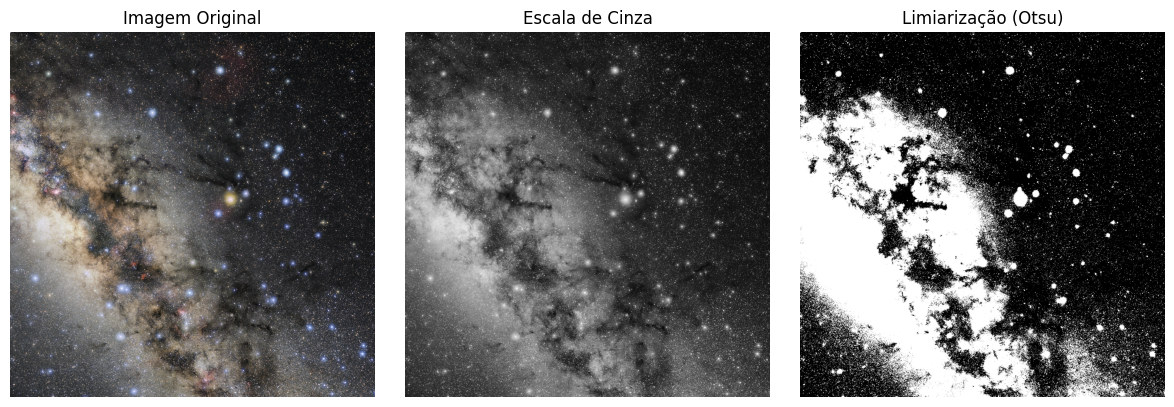

In [1]:
# Segmentação na Escala de Cinza e Otsu

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Por favor, faça o upload de uma imagem (ex: formato JPG ou PNG):")
uploaded = files.upload()

# Pega o nome do arquivo enviado
for filename in uploaded.keys():
    print(f"Arquivo carregado com sucesso: {filename}")

    # 1. Carregar a imagem colorida
    img_bgr = cv2.imread(filename)

    # Verificar se a imagem foi lida corretamente
    if img_bgr is None:
        print("Erro ao ler a imagem. Tente novamente com outro arquivo.")
        break

    # Converter de BGR (OpenCV) para RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Converter para escala de cinza
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 3. Aplicar limiarização de Otsu
    suave = cv2.GaussianBlur(img_gray, (5, 5), 0)
    _, thresh_otsu = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Exibir as imagens usando Matplotlib
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Escala de Cinza')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(thresh_otsu, cmap='gray')
    plt.title('Limiarização (Otsu)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Por favor, faça o upload de uma imagem (ex: formato JPG ou PNG):


Saving Andromeda.tif to Andromeda.tif
Arquivo carregado com sucesso: Andromeda.tif


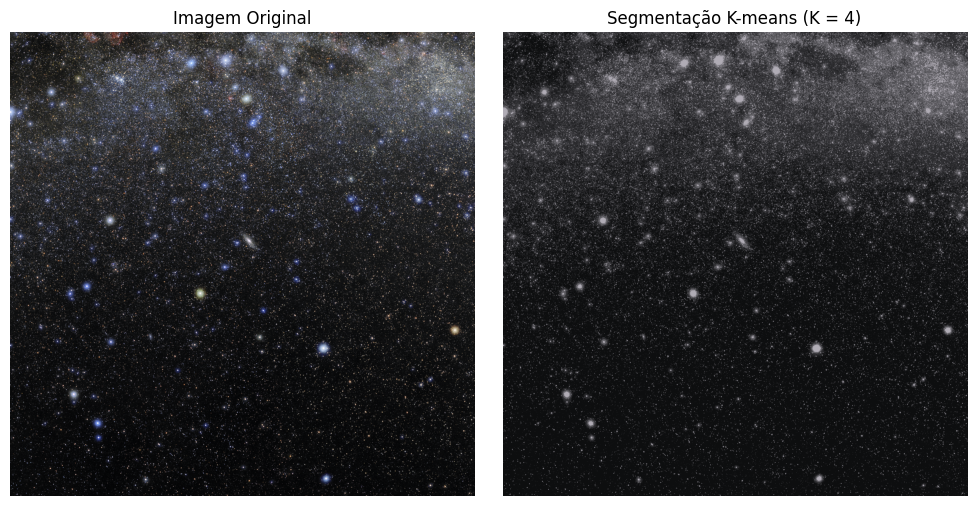

In [2]:
# Segmentação de Cores com K-means

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Por favor, faça o upload de uma imagem (ex: formato JPG ou PNG):")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"Arquivo carregado com sucesso: {filename}")

    # 1. Carregar a imagem colorida
    img_bgr = cv2.imread(filename)
    if img_bgr is None:
        print("Erro ao ler a imagem. Tente novamente.")
        break

    # Converter de BGR (OpenCV) para RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Preparar os dados para o K-means (achatar a imagem para uma lista de pixels RGB)
    pixel_values = img_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # 3. Definir critérios de Parada e o número de clusters (K)
    # Critério: 10 iterações ou precisão epsilon de 1.0
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    K = 4  # Você pode alterar este valor conforme a complexidade desejada

    # Executar o algoritmo K-means
    _, labels, (centers) = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # 4. Reconstruir a imagem segmentada usando os centros dos clusters
    centers = np.uint8(centers)
    segmented_data = centers[labels.flatten()]
    segmented_image = segmented_data.reshape(img_rgb.shape)

    # 5. Exibir a imagem original e a segmentada lado a lado
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_image)
    plt.title(f'Segmentação K-means (K = {K})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Por favor, faça o upload de uma imagem (ex: formato JPG ou PNG):


Saving Draco.tif to Draco.tif
Arquivo carregado com sucesso: Draco.tif


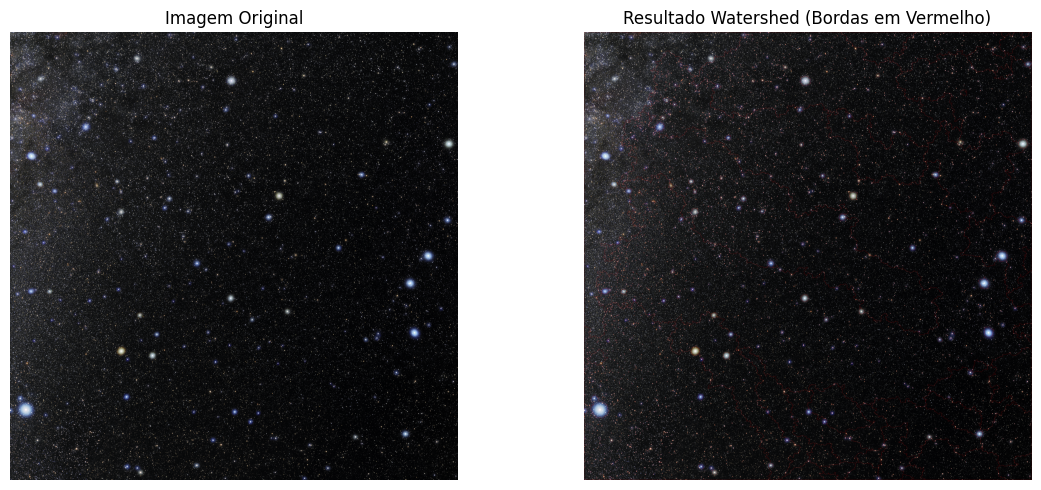

In [3]:
# Segmentação com Algoritmo Watershed

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Por favor, faça o upload de uma imagem (ex: formato JPG ou PNG):")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"Arquivo carregado com sucesso: {filename}")

    # 1. Carregar a imagem colorida
    img_bgr = cv2.imread(filename)
    if img_bgr is None:
        print("Erro ao ler a imagem. Tente novamente.")
        break

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. Limiarização de Otsu para binarização inicial
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Remoção de ruído com operações morfológicas (Abertura)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # 4. Área de fundo segura (Dilatação)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # 5. Área de primeiro plano segura (Transformada de Distância)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

    # 6. Encontrar a região desconhecida (fronteiras)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # 7. Rotulagem de marcadores
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # 8. Aplicar o algoritmo Watershed
    markers = cv2.watershed(img_bgr, markers)

    # Destacar as linhas de contorno na imagem original (marcador -1)
    img_result = img_rgb.copy()
    img_result[markers == -1] = [255, 0, 0]  # Vermelho para as bordas

    # 9. Exibir os resultados
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_result)
    plt.title('Resultado Watershed (Bordas em Vermelho)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Saving Libra.tif to Libra.tif


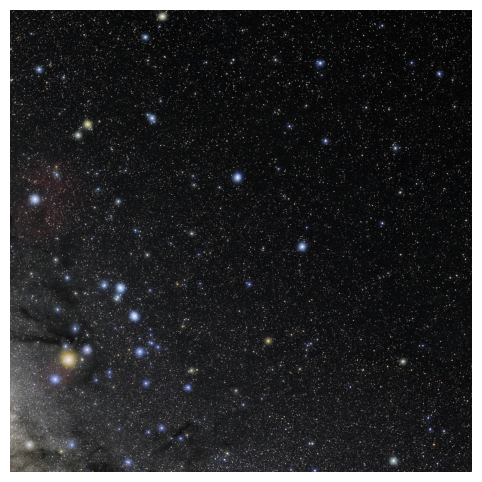

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2

from google.colab import files

uploaded = files.upload()

nome = list(uploaded.keys())[0]

img = cv2.imread(nome)

# OpenCV carrega em BGR, então convertemos para RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

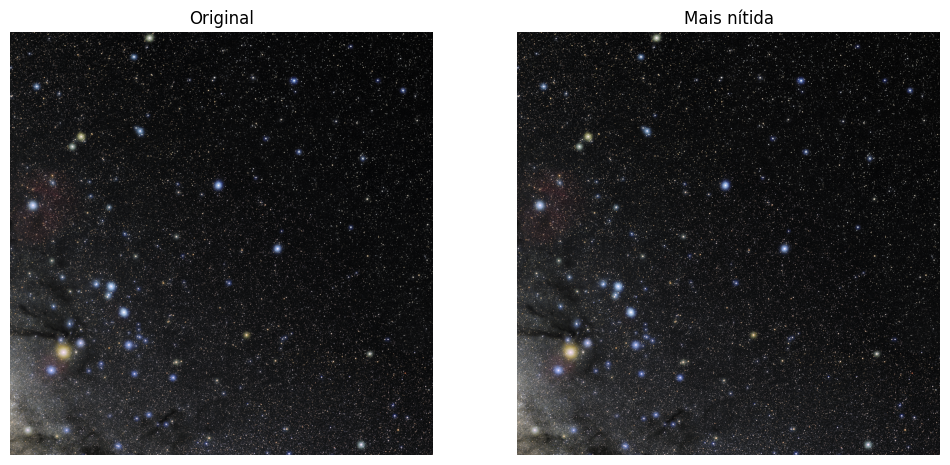

In [5]:
import numpy as np

kernel = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
])

nitida = cv2.filter2D(img, -1, kernel)

nitida_rgb = cv2.cvtColor(nitida, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(nitida_rgb)
plt.title("Mais nítida")
plt.axis("off")

plt.show()

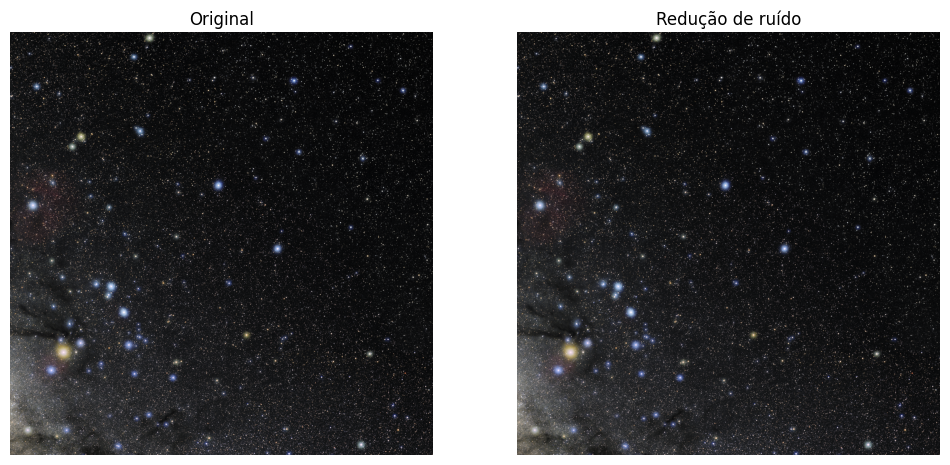

In [6]:
suave = cv2.bilateralFilter(
    img,
    d=9,
    sigmaColor=50,
    sigmaSpace=50
)

suave_rgb = cv2.cvtColor(suave, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(suave_rgb)
plt.title("Redução de ruído")
plt.axis("off")

plt.show()

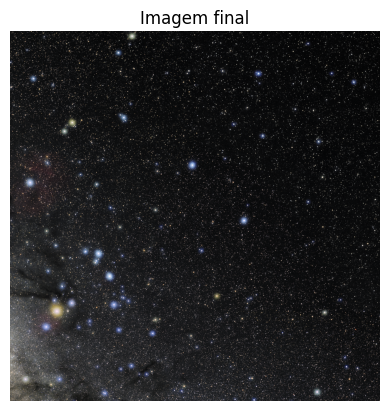

In [7]:
nitida = cv2.filter2D(suave, -1, kernel)

nitida_rgb = cv2.cvtColor(nitida, cv2.COLOR_BGR2RGB)

plt.imshow(nitida_rgb)
plt.title("Imagem final")
plt.axis("off")
plt.show()

In [8]:
# IA = Classificação baseada em Machine Learning

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

def extrair_caracteristicas(img_thresh, img_gray):
    """
    Extrai features numéricas da imagem processada (Otsu/Watershed)
    para alimentar o modelo de Inteligência Artificial.
    """
    # 1. Quantidade relativa de pixels de estrelas (área branca na binarização)
    total_pixels = img_thresh.size
    pixels_brancos = np.sum(img_thresh == 255)
    densidade_estelar = pixels_brancos / total_pixels

    # 2. Intensidade média e desvio padrão dos pixels na escala de cinza
    brilho_medio = np.mean(img_gray)
    desvio_brilho = np.std(img_gray)

    # Retorna um vetor de características (features)
    return [densidade_estelar, brilho_medio, desvio_brilho]

print("Gerando dataset simulado de treinamento para a IA...")
np.random.seed(42)

# Criando dados para 3 classes de constelações diferentes
# Features: [densidade_estelar, brilho_medio, desvio_brilho]
X_treino_simulado = []
y_treino_simulado = []

for _ in range(30): # 10 amostras por classe
    # Classe 0: Constelação A
    X_treino_simulado.append([np.random.uniform(0.15, 0.30), np.random.uniform(80, 110), np.random.uniform(40, 55)])
    y_treino_simulado.append("Scorpios")

    # Classe 1: Constelação B
    X_treino_simulado.append([np.random.uniform(0.05, 0.14), np.random.uniform(50, 79), np.random.uniform(25, 39)])
    y_treino_simulado.append("Andromeda")

    # Classe 2: Constelação C
    X_treino_simulado.append([np.random.uniform(0.01, 0.04), np.random.uniform(20, 49), np.random.uniform(10, 24)])
    y_treino_simulado.append("Libra")

# Extraindo features da imagem que o usuário acabou de enviar e processar
features_usuario = extrair_caracteristicas(thresh_otsu, img_gray)

# Treinando um modelo de Inteligência Artificial (Random Forest)
X = np.array(X_treino_simulado)
y = np.array(y_treino_simulado)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

# Realizando a predição na imagem enviada pelo usuário
predicao = clf.predict([features_usuario])[0]
probabilidades = clf.predict_proba([features_usuario])[0]
confianca_max = np.max(probabilidades) * 100

print("\n" + "="*40)
print("RESULTADO DA CLASSIFICAÇÃO POR INTELIGÊNCIA ARTIFICIAL:")
print(f"-> Características extraídas: {features_usuario}")
print(f"-> Constelação Predita pelo Modelo: {predicao}")
print(f"-> Confiança da Predição: {confianca_max:.2f}%")
print("="*40)

Gerando dataset simulado de treinamento para a IA...

RESULTADO DA CLASSIFICAÇÃO POR INTELIGÊNCIA ARTIFICIAL:
-> Características extraídas: [np.float64(0.3513772), np.float64(76.5661088), np.float64(50.88694536584564)]
-> Constelação Predita pelo Modelo: Scorpios
-> Confiança da Predição: 64.00%
